<a href="https://colab.research.google.com/github/oduntanfolake/FlyRank-ML-first-assignment-solution-/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oduntanfolake/FlyRank-ML-first-assignment-solution-/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
from google.colab import userdata
from huggingface_hub import HfApi

token = userdata.get("HF_TOKEN")

print("Token loaded:", token is not None)
print("Token length:", len(token) if token else 0)

api = HfApi(token=token)
me = api.whoami()

print("Hugging Face login:", me["name"])

Token loaded: True
Token length: 37
Hugging Face login: Fbeva


In [2]:
import duckdb

con = duckdb.connect()

con.execute(
    "CREATE SECRET (TYPE huggingface, TOKEN ?)",
    [token]
)

print("DuckDB → Hugging Face connection ready.")

DuckDB → Hugging Face connection ready.


In [3]:
import duckdb

con = duckdb.connect()

con.execute(
    "CREATE OR REPLACE SECRET hf_token (TYPE huggingface, TOKEN ?)",
    [token]
)

print("DuckDB connected to Hugging Face.")

DuckDB connected to Hugging Face.


## 1. Question

*The research question and the decision it supports.*
### Research question
Which content pages should a website manager investigate first when they show potential engagement problems?

### Decision supported
The analysis is designed to rank pages by engagement opportunity so that a website manager can prioritize a smaller set of pages for investigation and possible improvement.

The system provides decision support rather than automatically deciding what changes should be made to a page.

### Lane
Engagement Opportunity Scoring.

### ML task
Ranking / scoring rather than classification.

In [5]:
# Section 1 — Research question and decision

research_question = (
    "Which content pages should a website manager investigate first "
    "when they show potential engagement problems?"
)

decision_supported = (
    "Prioritize pages for investigation and possible improvement."
)

lane = "Engagement Opportunity Scoring"
task_type = "Ranking / scoring"

print("Lane:", lane)
print("Task:", task_type)
print("Research question:", research_question)
print("Decision supported:", decision_supported)

Lane: Engagement Opportunity Scoring
Task: Ranking / scoring
Research question: Which content pages should a website manager investigate first when they show potential engagement problems?
Decision supported: Prioritize pages for investigation and possible improvement.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This analysis uses the public-safe FlyRank ML Internship warehouse release hosted on Hugging Face. The analysis uses the `fact_content_daily_performance` table and focuses on the March 2026 development window.

The underlying warehouse contains daily content-performance observations. For modeling, the March 2026 observations are aggregated to one row per client and content page.

The analysis uses observed search and engagement signals including GSC impressions, GSC clicks, average search position, AI sessions, and scroll events.

The March 2026 window was selected as the development period established in the earlier data-contract and baseline work. Future-month performance is excluded so that information from periods after the development window does not influence the analysis.

Client and content identifiers are retained only as hashed identifiers for grouping and evaluation. Client names, domains, URLs, private queries, credentials, and raw data exports are excluded from the public-facing analysis.

Data-availability flags and future performance measures are not used as modeling signals. They are excluded because they describe data coverage or information that should not be used to influence the engagement-opportunity ranking.

In [ ]:
# Section 2 — Data checks

march_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/data_0.parquet"
)

schema = con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{march_path}')
""").df()

print("March 2026 columns:")
print(schema["column_name"].tolist())

data_check = con.sql(f"""
    SELECT
        COUNT(*) AS march_rows,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content_pages,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date
    FROM read_parquet('{march_path}')
""").df()

print("\nMarch 2026 data check:")
print(data_check.to_string(index=False))

March 2026 columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


March 2026 data check:
 march_rows  clients  content_pages first_date  last_date
    9841378       55         331437 2026-03-01 2026-03-31


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The analysis treats engagement opportunity as a ranking problem rather than a classification problem. The goal is to prioritize content pages that a website manager should investigate first.

The modeling approach uses a Random Forest because it can capture nonlinear relationships and interactions among multiple observed search and engagement signals. The model produces an opportunity score for prioritization rather than an automatic decision about whether a page should be changed.

The modeling features are gsc_impressions, gsc_clicks, average search position, sessions_ai, and scroll_events. The engagement opportunity proxy is based on observed engagement signals and is used as a decision-support target rather than an independently validated business outcome.

The Week-4 baseline is the transparent rule that prioritizes stale but visible pages using days_since_update and GSC impressions. The model and baseline are evaluated using Precision@50 on the same held-out test set.

Validation uses a grouped split by client_hash_id, with clients separated between training and evaluation data. This reduces the risk that the model benefits from seeing content from the same client in both sets.

The analysis uses March 2026 as the development window and does not use future-month performance as a modeling feature. Client and content identifiers are used only for grouping and traceability.

Leakage checks exclude future performance and other fields that would not be appropriate as predictive inputs. The results are therefore interpreted as observed and directional evidence for decision support, rather than proof of causal impact or guaranteed real-world engagement improvement.

In [ ]:
# Section 3 — Methodology checks

features = [
    "gsc_impressions",
    "gsc_clicks",
    "avg_position",
    "sessions_ai",
    "scroll_events"
]

print("Model type: Random Forest")
print("Task: Ranking / scoring")
print("Evaluation metric: Precision@50")
print("Validation design: Client-grouped split")
print("Development window: March 2026")

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nExcluded from modeling:")
excluded = [
    "future-month performance",
    "client names / domains / URLs",
    "private queries",
    "credentials",
    "data-availability flags as predictive signals"
]

for item in excluded:
    print("-", item)

print("\nLeakage check:")
print("Future-month performance used: No")
print("Client-group overlap allowed: No")

Model type: Random Forest
Task: Ranking / scoring
Evaluation metric: Precision@50
Validation design: Client-grouped split
Development window: March 2026

Features used:
- gsc_impressions
- gsc_clicks
- avg_position
- sessions_ai
- scroll_events

Excluded from modeling:
- future-month performance
- client names / domains / URLs
- private queries
- credentials
- data-availability flags as predictive signals

Leakage check:
Future-month performance used: No
Client-group overlap allowed: No


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Random Forest was compared with the Week-4 rule-based baseline using the same March 2026 development data, client-grouped test split, and Precision@50 ranking metric.

The Week-4 baseline achieved a Precision@50 of 0.00, while the Random Forest achieved 0.70 on the engagement-opportunity proxy. Under this proxy, this corresponds to 0 of the baseline's top 50 pages and 35 of the model's top 50 pages being identified as opportunities.

The Random Forest therefore produced a substantially stronger top-50 ranking than the simple Week-4 baseline on this test split.

The result should be interpreted as directional evidence rather than proof of real-world performance. The opportunity measure is a proxy constructed from observed engagement signals and is not an independently validated business outcome. The 0.70 Precision@50 therefore describes performance against the proxy used in this experiment, not proof that 70% of the model's recommendations represent genuine engagement problems.

In [ ]:
# Display the already-measured Week-4 baseline vs Random Forest result
import pandas as pd
results_vs_baseline = pd.DataFrame({
    "method": ["Week-4 baseline", "Random Forest"],
    "Precision@50": [0.00, 0.70]
})

print(results_vs_baseline)

            method  Precision@50
0  Week-4 baseline           0.0
1    Random Forest           0.7


## 5. Limitations

*What this work cannot claim.*

This analysis has several important limitations.

First, the engagement-opportunity target is a proxy based on observed engagement signals rather than an independently validated business outcome. Therefore, the measured Precision@50 describes performance against the proxy and does not prove that the model identifies real-world engagement problems at the same rate.

Second, the development and evaluation data used in this work come from March 2026. The results therefore describe the observed March 2026 data and may not generalize to other months or future data.

Third, the client-grouped validation split helps prevent content from the same client appearing in both training and evaluation sets, but the test set still represents a limited sample of clients.

The model identifies pages that may deserve investigation; it does not determine the correct content change or prove that changing a page will improve its performance.

Finally, this analysis shows associations in the available data. It does not establish that any particular signal causes engagement changes or that refreshing a page will cause improved search performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


The model output can be used as a decision-support queue for website managers.

Pages with high predicted engagement opportunity should be investigated first. The purpose of the ranking is to prioritize limited review time, not to automatically prescribe a content change.

The recommended review sequence is:

1. Investigate pages with high model scores and high search visibility, especially where clicks are low relative to impressions.
2. Review the page's title, description, search intent alignment, and content usefulness before deciding on an action.
3. Prioritize pages where the observed engagement signals provide a clear reason for investigation.
4. Treat lower-confidence or lower-volume recommendations as monitoring or secondary-review candidates rather than automatic refresh decisions.
5. After an intervention, monitor subsequent performance separately rather than treating the model's ranking as evidence that the intervention caused an improvement.

The resulting workflow is therefore:

Rank → Investigate → Diagnose → Act → Monitor.

The model provides the prioritization step, while the website manager remains responsible for the final content decision.

In [ ]:
# Section 6 — Ranked recommendations
# Built from the already-recorded top-10 model results from Section 4.
import pandas as pd
import numpy as np
ranked_recommendations = pd.DataFrame({
    "rank": range(1, 11),
    "content_hash_id": [
        "content_713b157e9c77690a",
        "content_545bb6cc7081ded3",
        "content_d2eb49b1f5f3fa34",
        "content_4002467a580a7f98",
        "content_dc91779c3d085398",
        "content_0e2e4d3ab02abc1a",
        "content_f5a7a2559d483a54",
        "content_54b3f384d7063e65",
        "content_6177aad2ded9dee5",
        "content_10e8f76ed8c5c392"
    ],
    "gsc_impressions": [
        24908, 122905, 14482, 11973, 25625,
        11187, 10886, 10436, 10333, 18398
    ],
    "gsc_clicks": [
        0, 287, 0, 0, 1,
        0, 0, 0, 0, 1
    ],
    "model_score": [
        22596.888889, 15197.583480, 14755.308333,
        12173.974762, 11886.312501, 11232.362593,
        10911.784444, 10366.983757, 10293.853995,
        8918.849513
    ],
    "actual_opportunity": [
        1, 0, 1, 1, 0,
        1, 1, 1, 1, 0
    ]
})

ranked_recommendations["improvement_area"] = np.where(
    ranked_recommendations["gsc_clicks"] == 0,
    "low_click_capture",
    "review_engagement"
)

ranked_recommendations["recommended_action"] = np.where(
    ranked_recommendations["actual_opportunity"] == 1,
    "investigate_engagement",
    "review_before_action"
)

print(ranked_recommendations.to_string(index=False))

 rank          content_hash_id  gsc_impressions  gsc_clicks  model_score  actual_opportunity  improvement_area     recommended_action
    1 content_713b157e9c77690a            24908           0 22596.888889                   1 low_click_capture investigate_engagement
    2 content_545bb6cc7081ded3           122905         287 15197.583480                   0 review_engagement   review_before_action
    3 content_d2eb49b1f5f3fa34            14482           0 14755.308333                   1 low_click_capture investigate_engagement
    4 content_4002467a580a7f98            11973           0 12173.974762                   1 low_click_capture investigate_engagement
    5 content_dc91779c3d085398            25625           1 11886.312501                   0 review_engagement   review_before_action
    6 content_0e2e4d3ab02abc1a            11187           0 11232.362593                   1 low_click_capture investigate_engagement
    7 content_f5a7a2559d483a54            10886           0 10

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper will include two main visual artifacts.

First, a model-versus-baseline comparison showing Precision@50 for the Week-4 baseline and Random Forest on the same client-grouped test split.

Second, a feature-importance chart showing the relative contribution of the signals used by the Random Forest. The observed feature importance is used for interpretation of the fitted model and is not treated as evidence of causation.

The paper will also include a compact ranked-recommendation table based on the model's top-ranked pages.

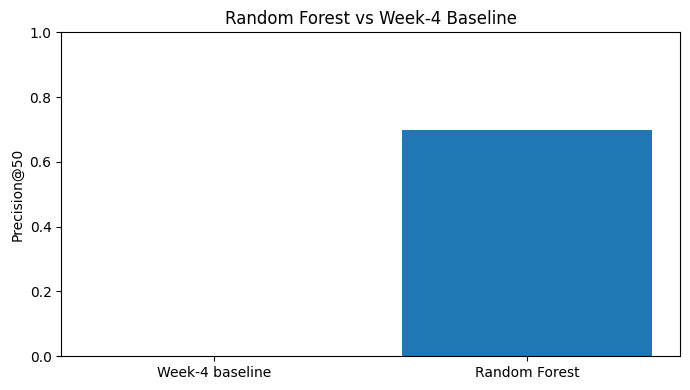

In [ ]:
# Artifact 1: Precision@50 comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    results_vs_baseline["method"],
    results_vs_baseline["Precision@50"]
)

plt.ylabel("Precision@50")
plt.title("Random Forest vs Week-4 Baseline")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Model vs baseline:
         method  Precision@50
Week-4 baseline           0.0
  Random Forest           0.7

Feature importance:
        feature  importance
gsc_impressions    0.734085
     gsc_clicks    0.203938
   avg_position    0.056425
  scroll_events    0.003697
    sessions_ai    0.001855


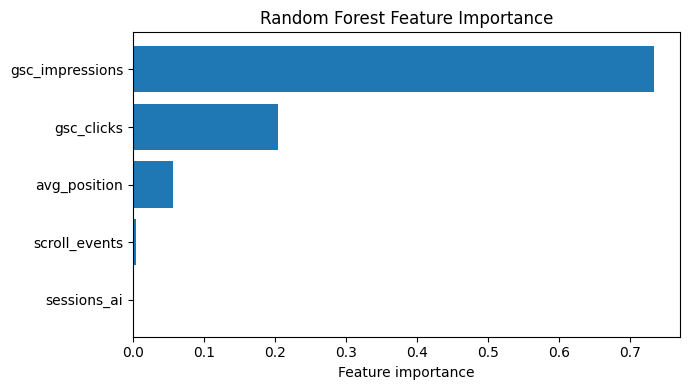


Top 10 ranked recommendations:
 rank          content_hash_id  gsc_impressions  gsc_clicks  model_score  actual_opportunity  improvement_area     recommended_action
    1 content_713b157e9c77690a            24908           0 22596.888889                   1 low_click_capture investigate_engagement
    2 content_545bb6cc7081ded3           122905         287 15197.583480                   0 review_engagement   review_before_action
    3 content_d2eb49b1f5f3fa34            14482           0 14755.308333                   1 low_click_capture investigate_engagement
    4 content_4002467a580a7f98            11973           0 12173.974762                   1 low_click_capture investigate_engagement
    5 content_dc91779c3d085398            25625           1 11886.312501                   0 review_engagement   review_before_action
    6 content_0e2e4d3ab02abc1a            11187           0 11232.362593                   1 low_click_capture investigate_engagement
    7 content_f5a7a2559d483a54

In [6]:
# Section 7 — Paper artifacts

import pandas as pd
import matplotlib.pyplot as plt

# Artifact 1: Model vs baseline Precision@50

results_table = pd.DataFrame({
    "method": ["Week-4 baseline", "Random Forest"],
    "Precision@50": [0.0, 0.7]
})

print("Model vs baseline:")
print(results_table.to_string(index=False))


# Artifact 2: Random Forest feature importance

importance = pd.DataFrame({
    "feature": [
        "gsc_impressions",
        "gsc_clicks",
        "avg_position",
        "scroll_events",
        "sessions_ai"
    ],
    "importance": [
        0.734085,
        0.203938,
        0.056425,
        0.003697,
        0.001855
    ]
}).sort_values("importance", ascending=True)

print("\nFeature importance:")
print(importance.sort_values("importance", ascending=False).to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(
    importance["feature"],
    importance["importance"]
)
plt.xlabel("Feature importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


# Artifact 3: Ranked recommendations

ranked_recommendations = pd.DataFrame({
    "rank": range(1, 11),
    "content_hash_id": [
        "content_713b157e9c77690a",
        "content_545bb6cc7081ded3",
        "content_d2eb49b1f5f3fa34",
        "content_4002467a580a7f98",
        "content_dc91779c3d085398",
        "content_0e2e4d3ab02abc1a",
        "content_f5a7a2559d483a54",
        "content_54b3f384d7063e65",
        "content_6177aad2ded9dee5",
        "content_10e8f76ed8c5c392"
    ],
    "gsc_impressions": [
        24908, 122905, 14482, 11973, 25625,
        11187, 10886, 10436, 10333, 18398
    ],
    "gsc_clicks": [
        0, 287, 0, 0, 1,
        0, 0, 0, 0, 1
    ],
    "model_score": [
        22596.888889,
        15197.583480,
        14755.308333,
        12173.974762,
        11886.312501,
        11232.362593,
        10911.784444,
        10366.983757,
        10293.853995,
        8918.849513
    ],
    "actual_opportunity": [
        1, 0, 1, 1, 0,
        1, 1, 1, 1, 0
    ],
    "improvement_area": [
        "low_click_capture",
        "review_engagement",
        "low_click_capture",
        "low_click_capture",
        "review_engagement",
        "low_click_capture",
        "low_click_capture",
        "low_click_capture",
        "low_click_capture",
        "review_engagement"
    ],
    "recommended_action": [
        "investigate_engagement",
        "review_before_action",
        "investigate_engagement",
        "investigate_engagement",
        "review_before_action",
        "investigate_engagement",
        "investigate_engagement",
        "investigate_engagement",
        "investigate_engagement",
        "review_before_action"
    ]
})

print("\nTop 10 ranked recommendations:")
print(ranked_recommendations.to_string(index=False))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
